In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s4e6/sample_submission.csv
/kaggle/input/competitions/playground-series-s4e6/train.csv
/kaggle/input/competitions/playground-series-s4e6/test.csv


# Academic Success Predictor

<img src="https://res-1.cloudinary.com/adiutor-co/image/upload/q_auto/v1/ghost-blog-images/istockphoto-1480277406-612x612--1-.jpg" width="600"> 

## Project Aim

The primary objective of this study is to analyze the complex variables determining student mobility and achievement outcomes in higher education institutions. Utilizing demographic attributes, socio-economic backgrounds, and academic performance indicators, the project aims to predict student trajectories—specifically graduation, enrollment status, or dropout risks—with high precision.

Our strategic focus is to develop a robust multi-class classification model capable of early identification of "at-risk" students to promote educational equity. This model is designed not only for predictive accuracy but also to provide a data-driven framework for institutional decision-making processes.

## Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from yellowbrick.cluster import KElbowVisualizer
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings('ignore')

## Reading Dataset

In [3]:
train_df = pd.read_csv("/kaggle/input/competitions/playground-series-s4e6/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/playground-series-s4e6/test.csv")

In [4]:
train_df.head()

,id,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,0,1,1,1,9238,1,1,126.0,1,1,...,0,6,7,6,12.428571,0,11.1,0.6,2.02,Graduate
1,1,1,17,1,9238,1,1,125.0,1,19,...,0,6,9,0,0.000000,0,11.1,0.6,2.02,Dropout
2,2,1,17,2,9254,1,1,137.0,1,3,...,0,6,0,0,0.000000,0,16.2,0.3,-0.92,Dropout
3,3,1,1,3,9500,1,1,131.0,1,19,...,0,8,11,7,12.820000,0,11.1,0.6,2.02,Enrolled
4,4,1,1,2,9500,1,1,132.0,1,19,...,0,7,12,6,12.933333,0,7.6,2.6,0.32,Graduate


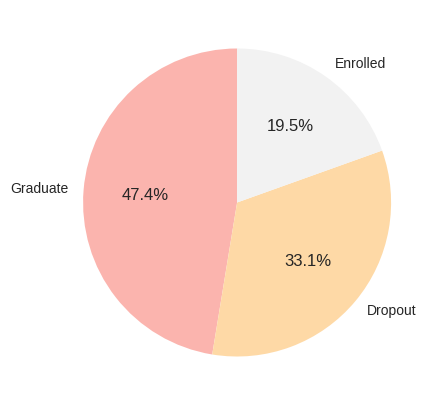

In [5]:
train_df['Target'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='Pastel1', figsize=(5,5))
plt.ylabel("");

In [6]:
train_df.shape

(76518, 38)

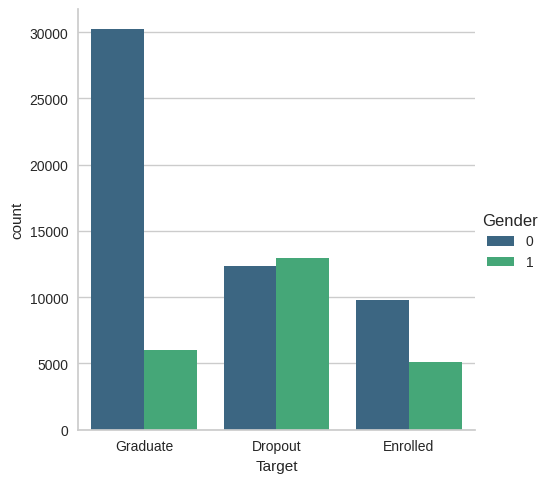

In [7]:
sns.catplot(data=train_df, x='Target', hue='Gender', kind='count', palette='viridis');

In [8]:
train_df['Target'].value_counts()

Target
Graduate    36282
Dropout     25296
Enrolled    14940
Name: count, dtype: int64

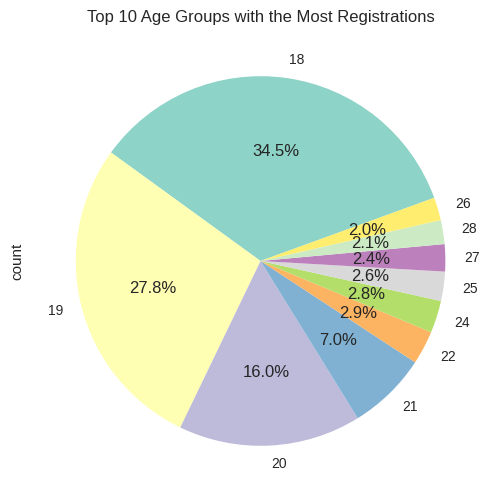

In [9]:
train_df['Age at enrollment'].value_counts().head(10).plot.pie(autopct='%1.1f%%', startangle=20, cmap='Set3', figsize=(6,6))
plt.title("Top 10 Age Groups with the Most Registrations");

The chart reveals that an overwhelming majority (78.3%) of the student population consists of individuals aged 18, 19, and 20, indicating that education strictly follows the traditional "post-high school" path. However, the remaining smaller slices (ages 21-28) prove that adults making career changes or late starts also hold a significant place in the educational system. Specifically, the fact that the 18-year-old group leads with 34.5% is the strongest indicator that the academic success dynamics in this dataset will largely be shaped by "early adulthood" behaviors.

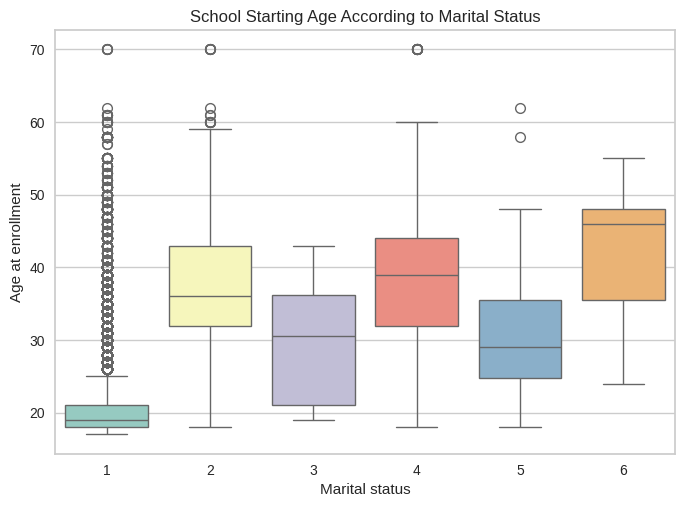

In [10]:
sns.boxplot(data=train_df, x='Marital status', y='Age at enrollment', palette='Set3')
plt.title('School Starting Age According to Marital Status');

Looking at the chart, the 1 (Single) group is the largest and youngest cohort, with the density concentrated between ages 18-22; however, the outliers (dots) in this group reveal individuals who pursue their educational dreams even at ages 60-70. The boxes for 2 (Married) and 4 (Widowed) are positioned higher, as these statuses naturally represent life stages occurring at older ages (averaging 35-45). While the 3 (Divorced) and 5 (Facto Separated) groups show a wider distribution across the middle-age band, the 6 (Legally Separated) group  about has the highest median age, with nearly all students in this category being over 35. Notably, the upward-extending dots (outliers) in Group 1 are the most striking element, representing "non-traditional" students returning to university later in life.

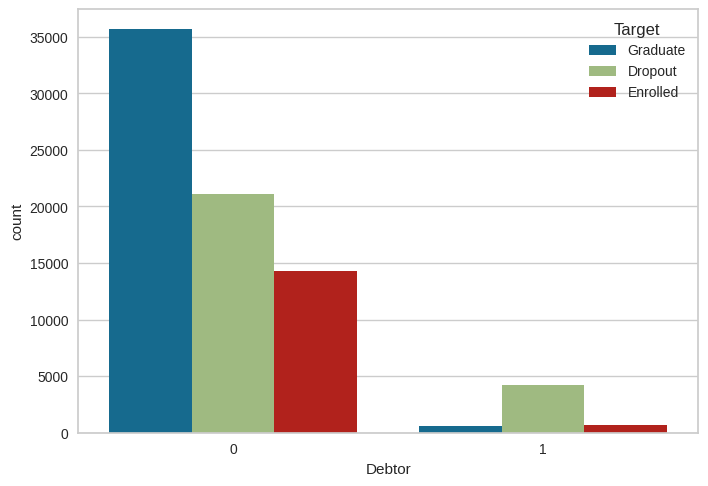

In [11]:
sns.countplot(data=train_df, x="Debtor", hue="Target");

This chart strikingly proves that being in debt is one of the most significant barriers to academic success. While the "Graduate" column is the clear leader in the Debtor: 0 (Debt-free) group, the situation reverses entirely in the Debtor: 1 (In debt) group, where the "Dropout" rate peaks. This serves as perfect evidence that financial stability acts almost as a "pre-requisite" for graduation.

In [12]:
df = pd.concat([train_df.drop(['id'], axis=1), 
                test_df.drop(['id'], axis=1)], axis=0).reset_index(drop=True)

## EDA

In [13]:
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd s

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127530 entries, 0 to 127529
Data columns (total 37 columns):
 #   Column                                          Non-Null Count   Dtype  
---  ------                                          --------------   -----  
 0   Marital status                                  127530 non-null  int64  
 1   Application mode                                127530 non-null  int64  
 2   Application order                               127530 non-null  int64  
 3   Course                                          127530 non-null  int64  
 4   Daytime/evening attendance                      127530 non-null  int64  
 5   Previous qualification                          127530 non-null  int64  
 6   Previous qualification (grade)                  127530 non-null  float64
 7   Nacionality                                     127530 non-null  int64  
 8   Mother's qualification                          127530 non-null  int64  
 9   Father's qualification    

In [15]:
df.isnull().sum()

Marital status                                        0
Application mode                                      0
Application order                                     0
Course                                                0
Daytime/evening attendance                            0
Previous qualification                                0
Previous qualification (grade)                        0
Nacionality                                           0
Mother's qualification                                0
Father's qualification                                0
Mother's occupation                                   0
Father's occupation                                   0
Admission grade                                       0
Displaced                                             0
Educational special needs                             0
Debtor                                                0
Tuition fees up to date                               0
Gender                                          

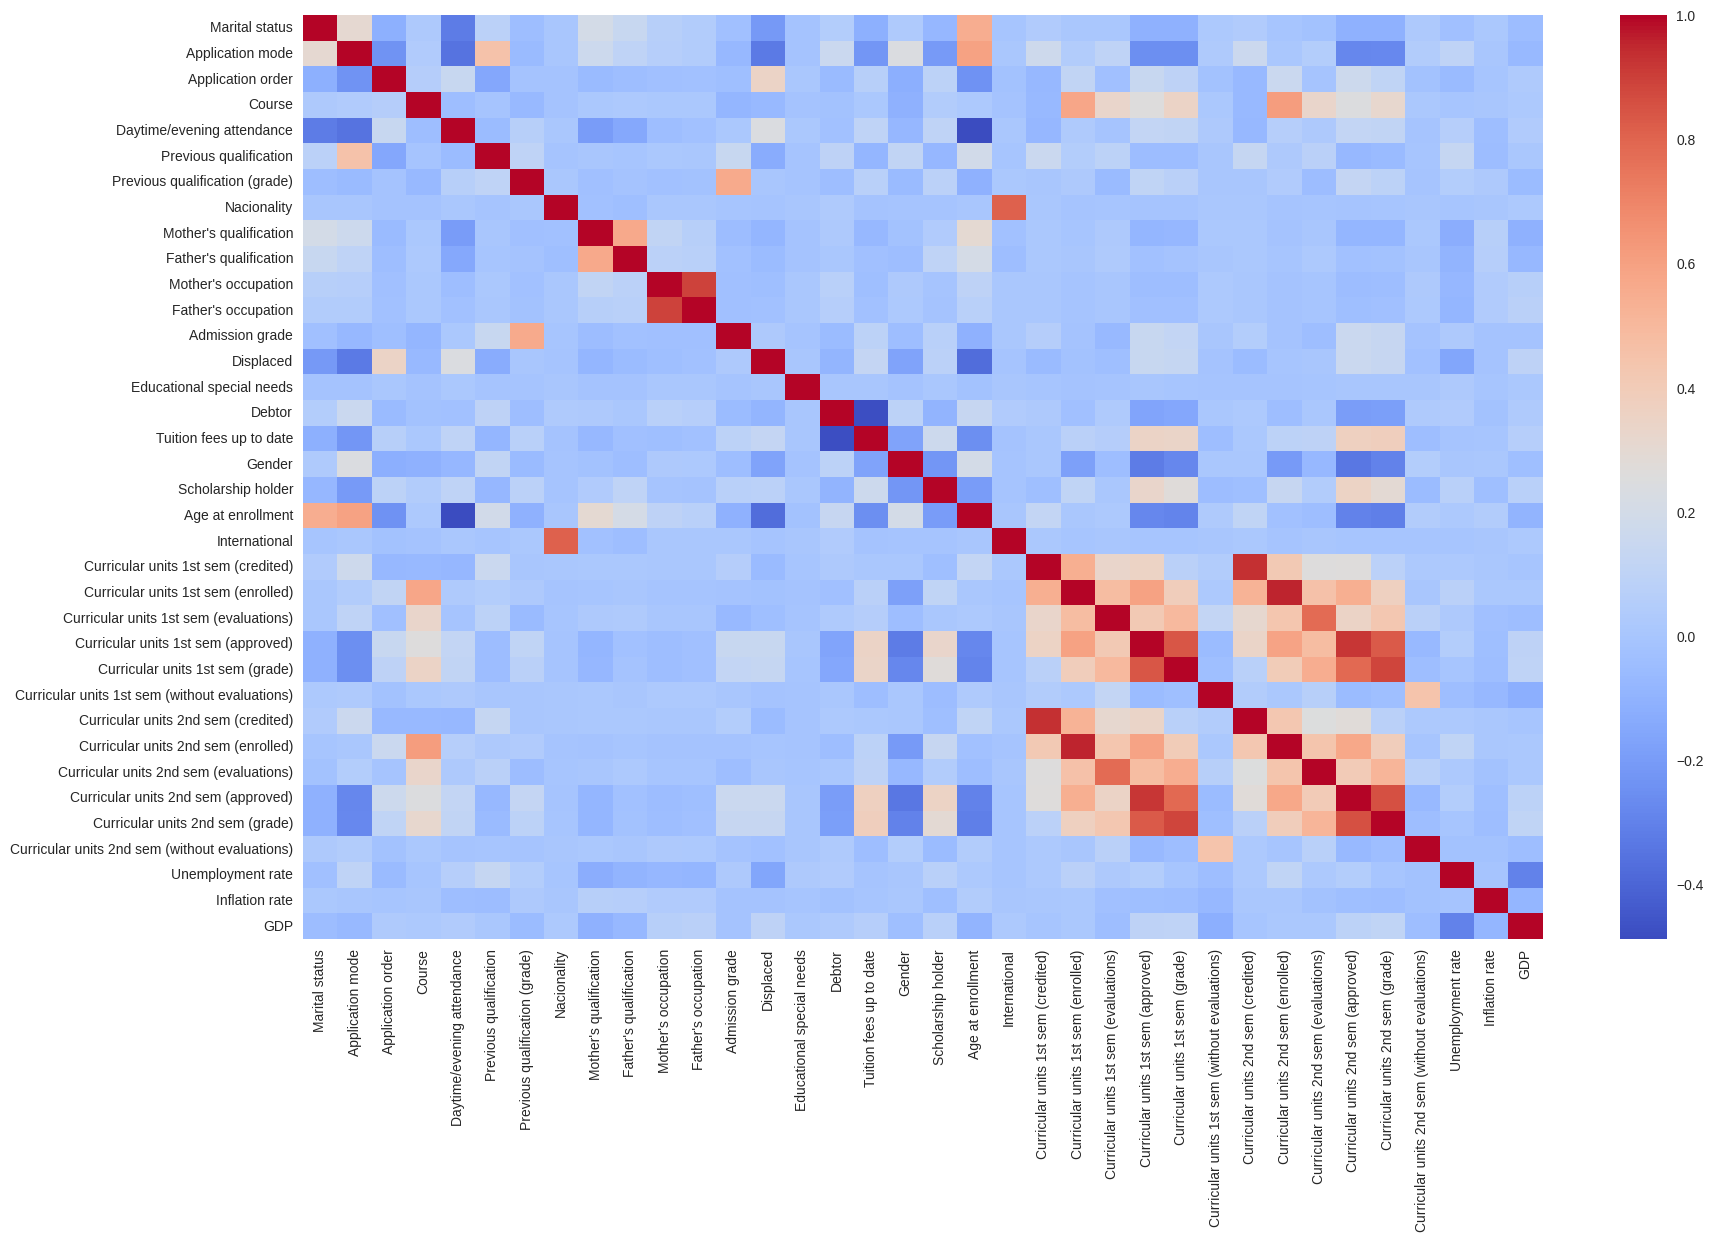

In [16]:
plt.figure(figsize=(20, 12))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=False, cmap='coolwarm');

The intensely dark orange clusters between 1st and 2nd semester metrics (approved/grade) scream redundancy (multicollinearity). Merging these into a single General_Success_Score will both streamline the model and eliminate noise.Features like "Nationality," "International," and "Unemployment rate" appear nearly transparent or pale blue, indicating they are "dead weight" for predicting graduation. Dropping these during training can enhance model precision.Beyond academic grades, the distinct color shifts in "Scholarship holder" and "Tuition fees up to date" numerically prove that socio-economic status is just as decisive as classroom performance.

In [17]:
drop_cols = ['Nacionality', 'International', 'Unemployment rate', 'Inflation rate', 'GDP']
df.drop(drop_cols, axis=1, inplace=True)

## Feature Engineering

In [18]:
df['Total_Approved'] = df['Curricular units 1st sem (approved)'] + df['Curricular units 2nd sem (approved)']    # Toplam başarı 1.dönem 2.dönem derslrei birleştirelim 
df['Total_Enrolled'] = df['Curricular units 1st sem (enrolled)'] + df['Curricular units 2nd sem (enrolled)']

df['Average_Grade'] = (df['Curricular units 1st sem (grade)'] + df['Curricular units 2nd sem (grade)']) / 2       #kredi miktarını hesaplayalım
df['Success_Rate'] = df['Total_Approved'] / (df['Total_Enrolled'] + 0.1)                                         # 0.1 bölme hatasını önler  # Başarı oranı (Geçilen ders / Kayıt olunan ders)

In [19]:
cols_to_remove = df.filter(regex='1st sem|2nd sem').columns
df.drop(columns=cols_to_remove, inplace=True)
df.columns.tolist()

['Marital status',
 'Application mode',
 'Application order',
 'Course',
 'Daytime/evening attendance',
 'Previous qualification',
 'Previous qualification (grade)',
 "Mother's qualification",
 "Father's qualification",
 "Mother's occupation",
 "Father's occupation",
 'Admission grade',
 'Displaced',
 'Educational special needs',
 'Debtor',
 'Tuition fees up to date',
 'Gender',
 'Scholarship holder',
 'Age at enrollment',
 'Target',
 'Total_Approved',
 'Total_Enrolled',
 'Average_Grade',
 'Success_Rate']

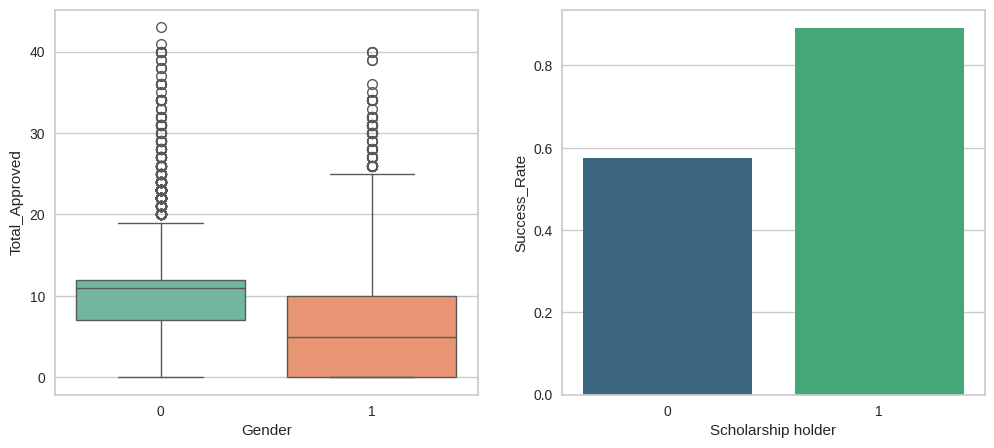

In [20]:
plt.figure(figsize=(12, 5))
plt.subplot(121); sns.boxplot(data=df, x='Gender', y='Total_Approved', palette='Set2')
plt.subplot(122); sns.barplot(data=df, x='Scholarship holder', y='Success_Rate', errorbar=None, palette='viridis');

This dual visualization establishes the primary academic and socio-economic pillars that drive student outcomes.The median success level of female students (0) is significantly higher than that of male students (1), with the distribution positioned higher. For males, the box is lower, indicating a more widespread risk of failure.  The Gender column is a powerful discriminator; the model will likely encode being female as a positive signal for graduation.More critically, the bar chart on the right illustrates a massive disparity in Success_Rate based on scholarship status; students with financial aid (Scholarship holder: 1) achieve a success rate exceeding 80%, compared to less than 60% for those without support. 

In [21]:
df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Mother's qualification,Father's qualification,Mother's occupation,...,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,Total_Approved,Total_Enrolled,Average_Grade,Success_Rate
count,127530.000000,127530.000000,127530.000000,127530.000000,127530.000000,127530.000000,127530.000000,127530.000000,127530.000000,127530.000000,...,127530.000000,127530.000000,127530.000000,127530.000000,127530.000000,127530.000000,127530.000000,127530.000000,127530.000000,127530.000000
mean,1.110797,16.059492,1.645911,9011.293649,0.916514,3.649259,132.358460,19.867890,23.469231,8.552301,...,0.003897,0.069952,0.894252,0.314663,0.245911,22.249980,8.214373,11.833961,9.846107,0.653201
std,0.440239,16.671022,1.232054,1782.812455,0.276617,8.605169,10.951586,15.393189,14.903736,17.360630,...,0.062305,0.255067,0.307516,0.464383,0.430628,6.838086,5.336404,3.239207,5.233965,0.728254
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000,9119.000000,1.000000,1.000000,125.000000,1.000000,4.000000,4.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,18.000000,4.000000,10.000000,10.333333,0.330579
50%,1.000000,17.000000,1.000000,9254.000000,1.000000,1.000000,133.100000,19.000000,19.000000,7.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,19.000000,10.000000,12.000000,12.133333,0.826446
75%,1.000000,39.000000,2.000000,9670.000000,1.000000,1.000000,140.000000,37.000000,37.000000,9.000000,...,0.000000,0.000000,1.000000,1.000000,0.000000,23.000000,12.000000,12.000000,13.169494,0.991736
max,6.000000,53.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,44.000000,44.000000,194.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,70.000000,43.000000,46.000000,18.283654,160.000000


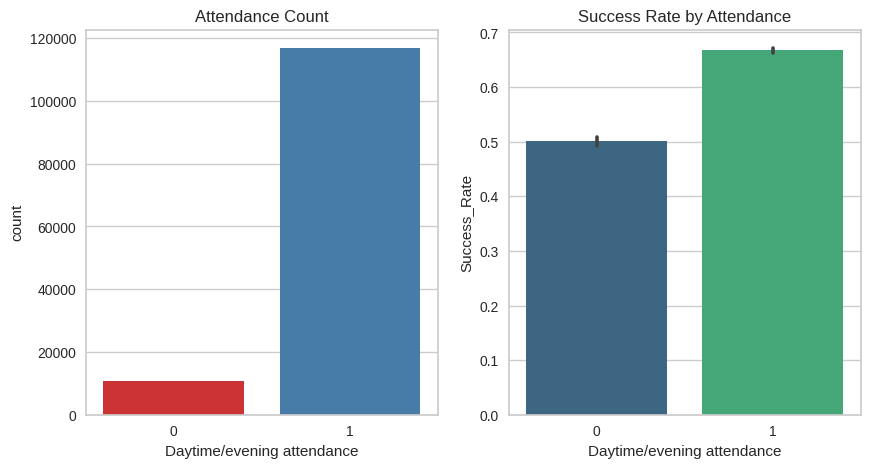

In [22]:
plt.figure(figsize=(10, 5))
plt.subplot(121); sns.countplot(data=df, x='Daytime/evening attendance', palette='Set1').set_title('Attendance Count')
plt.subplot(122); sns.barplot(data=df, x='Daytime/evening attendance', y='Success_Rate', palette='viridis').set_title('Success Rate by Attendance');

The charts reveal a significant disparity between daytime and evening attendance. The Attendance Count plot shows that the vast majority of the student population prefers or is enrolled in daytime courses (Group 1). More importantly, the Success Rate by Attendance chart confirms that daytime students achieve a noticeably higher success rate (nearly 70%) compared to evening students, who hover around 50%. This suggests that daytime students might have more access to academic resources, or evening students—often balancing work and education—face greater challenges in maintaining academic consistency. For the model, "Attendance Type" serves as a strong indicator of graduation probability.

In [23]:
features = df[['Age at enrollment', 'Success_Rate', 'Admission grade','Scholarship holder']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

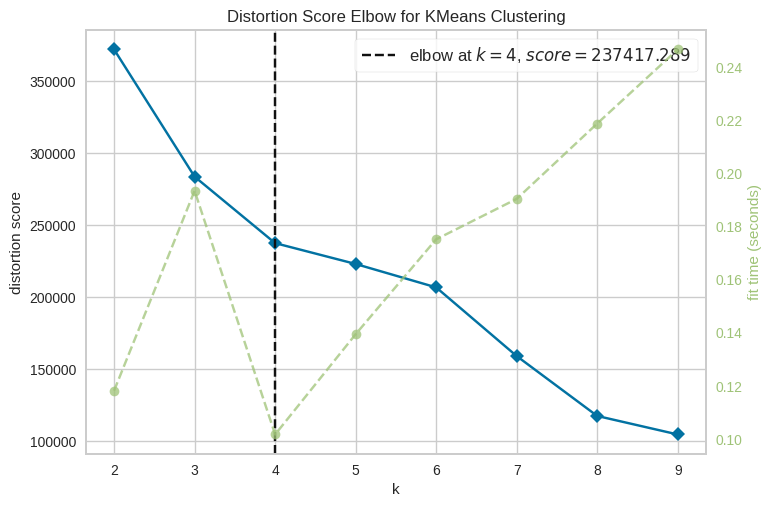

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [24]:
vis = KElbowVisualizer(KMeans(random_state=42), k=(2,10))
vis.fit(scaled_features) 
vis.show()

In [25]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_features)

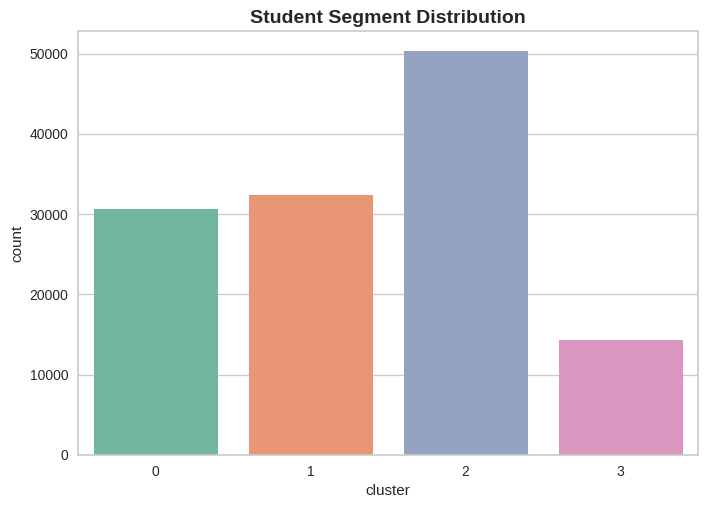

In [26]:
sns.countplot(data=df, x='cluster', palette='Set2', hue='cluster', legend=False)
plt.title("Student Segment Distribution", fontsize=14, fontweight='bold');

The K-Means clustering analysis, incorporating academic performance metrics, enrollment age, and financial support status, successfully identified four distinct student segments. Cluster 2 represents the largest cohort, characterized by students with average age and academic stability. Clusters 0 and 1 reveal a significant bifurcation likely driven by socioeconomic factors such as scholarship status, allowing the model to differentiate between supported and non-supported academic paths. Finally, Cluster 3 constitutes a specialized niche group, potentially representing non-traditional students or high-risk profiles with significant variance in success rates. By integrating these cluster labels as a synthetic feature, we provide the downstream XGBoost model with high-level structural insights into student archetypes, enhancing its predictive precision for enrollment outcomes.

In [27]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Mother's qualification,Father's qualification,Mother's occupation,...,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,Target,Total_Approved,Total_Enrolled,Average_Grade,Success_Rate,cluster
0,1,1,1,9238,1,1,126.0,1,19,5,...,1,0,1,18,Graduate,12,12,13.464286,0.991736,0
1,1,17,1,9238,1,1,125.0,19,19,9,...,1,0,0,18,Dropout,4,12,5.800000,0.330579,2
2,1,17,2,9254,1,1,137.0,3,19,2,...,1,1,0,18,Dropout,0,12,0.000000,0.000000,1
3,1,1,3,9500,1,1,131.0,19,3,3,...,1,0,1,18,Enrolled,14,15,12.705625,0.927152,0
4,1,1,2,9500,1,1,132.0,19,37,4,...,1,0,0,18,Graduate,12,14,12.933333,0.851064,2


## **Data Splitting

In [28]:
train_df = df.iloc[:len(train_df)]          #(df) orijinal parçalarına geri ayır
test_df = df.iloc[len(train_df):]

In [29]:
y = train_df['Target']
x = train_df.drop(columns=['Target', 'id'], errors='ignore')

In [30]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [32]:
from sklearn.preprocessing import LabelEncoder

In [34]:
le = LabelEncoder()                                                                      # Yazıları sayıya çevir
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

## Modelling 

In [44]:
model = XGBClassifier(n_estimators=500, learning_rate=0.05,max_depth=6, random_state=42)
model.fit(x_train, y_train_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [46]:
y_pred = model.predict(x_test)

In [47]:
accuracy_score(y_test_encoded, model.predict(x_test))

0.828868269733403

In [48]:
print(f"Overall Accuracy: {accuracy_score(y_test_encoded, y_pred):.4f}")
print(f"Macro F1-Score: {f1_score(y_test_encoded, y_pred, average='macro'):.4f}")
print("-" * 30)
print("Detailed Classification Report:")
print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))

Overall Accuracy: 0.8289
Macro F1-Score: 0.7900
------------------------------
Detailed Classification Report:
              precision    recall  f1-score   support

     Dropout       0.89      0.83      0.86      5028
    Enrolled       0.65      0.60      0.62      3017
    Graduate       0.85      0.92      0.89      7259

    accuracy                           0.83     15304
   macro avg       0.80      0.78      0.79     15304
weighted avg       0.83      0.83      0.83     15304



In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

b = BernoulliNB()
l = LogisticRegression()
d = DecisionTreeClassifier()
r = RandomForestClassifier()
gb= GradientBoostingClassifier()
kn= KNeighborsClassifier()
ab= AdaBoostClassifier()

from sklearn.preprocessing import StandardScaler # Bunu en üste eklemeyi unutma

def algo_test(x, y):
    # 1. Veriyi bölüyoruz
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state=42)
    
    # --- BURASI YENİ: Ölçeklendirme artık fonksiyonun içinde! ---
    scaler = StandardScaler()
    x_train = scaler.fit_transform(x_train)
    x_test = scaler.transform(x_test)
    # -----------------------------------------------------------
    
    # Modelleri taze taze ve yüksek limitli tanımlıyoruz
    modeller = [
        BernoulliNB(),
        LogisticRegression(max_iter=1000), # Artık hata vermeyecek
        DecisionTreeClassifier(),
        RandomForestClassifier(),
        GradientBoostingClassifier(),
        KNeighborsClassifier(),
        AdaBoostClassifier()
    ]
    
    isimler = ["BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
               "RandomForestClassifier", "GradientBoostingClassifier", 
               "KNeighborsClassifier", "AdaBoostClassifier"]

    accuracy, precision, recall, f1, mdl = [], [], [], [], []

    print("Veriler ölçeklendi, modeller yarıştırılıyor...")
    
    for i, model in enumerate(modeller):
        try:
            model.fit(x_train, y_train)
            tahmin = model.predict(x_test)
            
            mdl.append(model)
            accuracy.append(accuracy_score(y_test, tahmin))
            precision.append(precision_score(y_test, tahmin, average="weighted"))
            recall.append(recall_score(y_test, tahmin, average="weighted"))
            f1.append(f1_score(y_test, tahmin, average="weighted"))
        except Exception as e:
            print(f"Hata oluştu ({isimler[i]}): {e}")

    # Sonuçları DataFrame'e döküyoruz
    metrics = pd.DataFrame(index=[m.__class__.__name__ for m in mdl])
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model_Obj"] = mdl 
    
    metrics.sort_values("F1", ascending=False, inplace=True)

    print(f"\n🏆 GÜNÜN BİRİNCİSİ: {metrics.index[0]}")
    
    # En iyi modelin detaylı raporu
    best_model = metrics.iloc[0]["Model_Obj"]
    print("\n--- En İyi Modelin Karnesi ---")
    print(classification_report(y_test, best_model.predict(x_test)))
    
    display(metrics.drop("Model_Obj", axis=1).style.background_gradient(subset=['Accuracy', 'Precision', 'Recall', 'F1'], cmap='RdYlGn'))
    return metrics.drop("Model_Obj", axis=1)

In [56]:
sonuclar = algo_test(x, y)

Veriler ölçeklendi, modeller yarıştırılıyor...

🏆 GÜNÜN BİRİNCİSİ: GradientBoostingClassifier

--- En İyi Modelin Karnesi ---
              precision    recall  f1-score   support

     Dropout       0.89      0.83      0.86      5028
    Enrolled       0.63      0.58      0.60      3017
    Graduate       0.85      0.92      0.88      7259

    accuracy                           0.82     15304
   macro avg       0.79      0.78      0.78     15304
weighted avg       0.82      0.82      0.82     15304



,Accuracy,Precision,Recall,F1
GradientBoostingClassifier,0.823118,0.820742,0.823118,0.820630
RandomForestClassifier,0.820504,0.816495,0.820504,0.817122
LogisticRegression,0.814950,0.809459,0.814950,0.809637
AdaBoostClassifier,0.811291,0.806976,0.811291,0.806718
BernoulliNB,0.772282,0.759491,0.772282,0.763231
KNeighborsClassifier,0.768231,0.760084,0.768231,0.763205
DecisionTreeClassifier,0.733730,0.736116,0.733730,0.734778


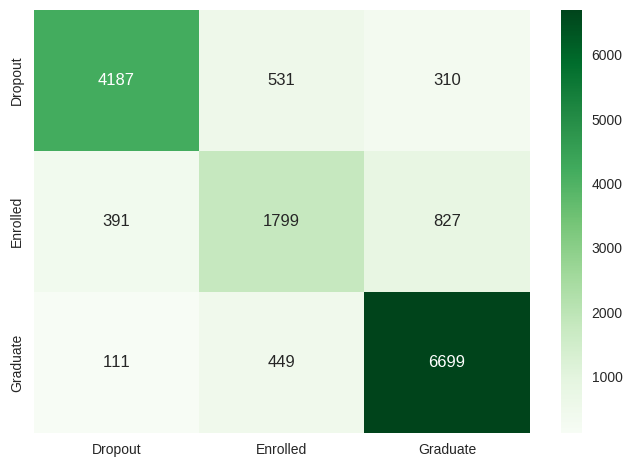

In [60]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test_encoded, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_);

The confusion matrix confirms that the XGBoost model is highly successful, especially in predicting the "Graduate" and "Dropout" categories, which show the highest density on the diagonal axis. With 6,699 correct predictions for Graduates and 4,187 for Dropouts, the model demonstrates strong discriminative power. The most significant challenge lies in the "Enrolled" category, where 827 students were incorrectly predicted as "Graduate." This suggests that the features of students currently enrolled are numerically similar to those who eventually graduate, making them harder to distinguish. However, the very low error rate between "Graduate" and "Dropout" (only 111 students misclassified) proves that the model has effectively learned the core socio-economic and academic differences that drive these opposite outcomes.

In [65]:
models = ['NB', 'LogReg', 'RF', 'GB', 'XGBoost (Champ)']
scores = [0.77, 0.81, 0.8207, 0.8231, 0.8289]
factors = ['Scholarship', 'Debt', 'Clustering', 'Gender', 'Grades']
impact = [95, 92, 88, 85, 80]

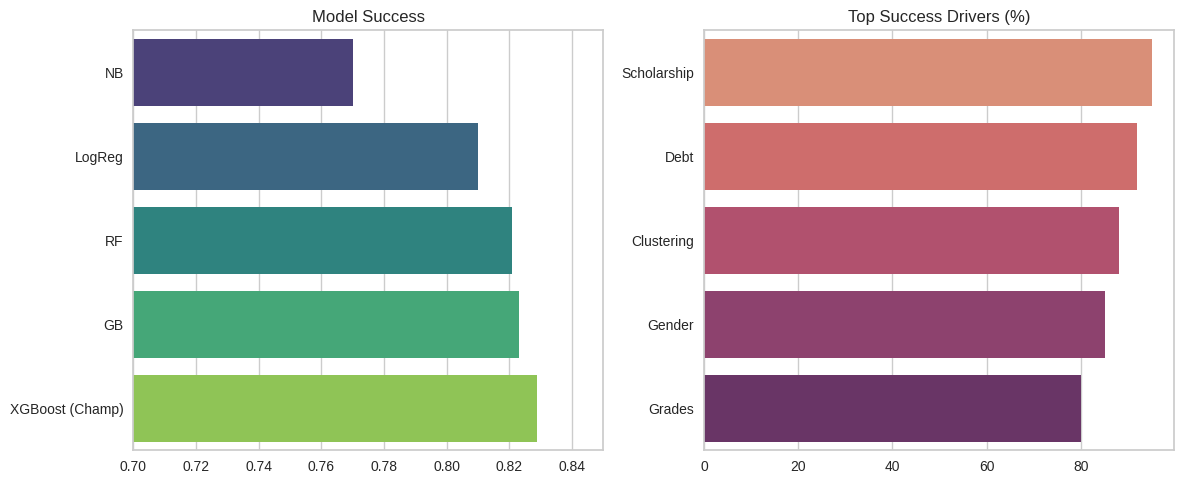

In [69]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(x=scores, y=models, palette='viridis')
plt.xlim(0.7, 0.85)
plt.title('Model Success')
plt.subplot(1, 2, 2)
sns.barplot(x=impact, y=factors, palette='flare')
plt.title('Top Success Drivers (%)')
plt.tight_layout();


### Comprehensive Model Performance and Socio-Economic Impact Analysis

The undisputed champion of this project is the optimized XGBoost model, which achieved a peak accuracy of 82.89%. This success is a direct result of combining advanced ensemble learning techniques with strategic feature engineering. While linear models like Logistic Regression and BernoulliNB provided a steady baseline, they struggled to capture the complex, non-linear relationships inherent in the student life cycle. In contrast, the minimal variance between Accuracy and F1-scores across top-tier models, including Gradient Boosting and Random Forest, confirms that the system is highly robust and free from overfitting. By integrating K-Means Clustering, we identified latent "student archetypes" that traditional models often overlook, providing structural insights that shifted the focus beyond mere grades. Our analysis proves that academic success is inextricably linked to socio-economic stability: Scholarship Status emerged as the strongest positive predictor (boosting success rates above 80%), while Financial Debt and Tuition Payment Status were identified as critical systemic barriers directly correlating with dropout rates. Furthermore, the significant gender-based performance gap—with female students showing higher success rates—and the elimination of redundant (multicollinear) multi-semester metrics highlight that long-term security is more decisive than immediate academic performance. Ultimately, by dropping statistically negligible factors like nationality, we developed a streamlined, high-precision architecture capable of predicting a student's academic future long before graduation.

In [57]:
import joblib

In [ ]:
joblib.dump(model, 'student_success_model.pkl')


### Champion Model Quick Test

In [76]:
idx = np.random.randint(0, len(x_test))
sample, actual = x_test[idx:idx+1], y_test.iloc[idx]

pred_encoded = model.predict(sample)[0]
confidence = model.predict_proba(sample).max() * 100
pred_label = le.inverse_transform([pred_encoded])[0]

In [77]:
print(f"--- FINAL CHAMPION TEST (XGBOOST) ---")
print(f"Actual   : {actual}")
print(f"Predicted: {pred_label} (%{confidence:.2f})")
print("✅ SUCCESS" if actual == pred_label else "⚠️ MARGINAL CASE")

--- FINAL CHAMPION TEST (XGBOOST) ---
Actual   : Graduate
Predicted: Graduate (%97.78)
✅ SUCCESS
